LDA (Linear Discriminant Analysis)

StandardScaler → LDA → explained variance → Plot 2D

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


StandardScaler

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


Mean ≈ 0
Std ≈ 1

LDA (ที่ใช้ 2 เพราะเรามี 3 class)

In [5]:
lda = LinearDiscriminantAnalysis(n_components=2)

In [6]:
X_lda = lda.fit_transform(X_scaled, y)

print("Original shape:", X.shape)
print("LDA shape:", X_lda.shape)

Original shape: (150, 4)
LDA shape: (150, 2)


Explained Variance Ratio

In [8]:
print(lda.explained_variance_ratio_)

[0.9912126 0.0087874]


In [9]:
for i, value in enumerate(lda.explained_variance_ratio_):
    print(f"LD{i+1}: {value:.2%}")

LD1: 99.12%
LD2: 0.88%


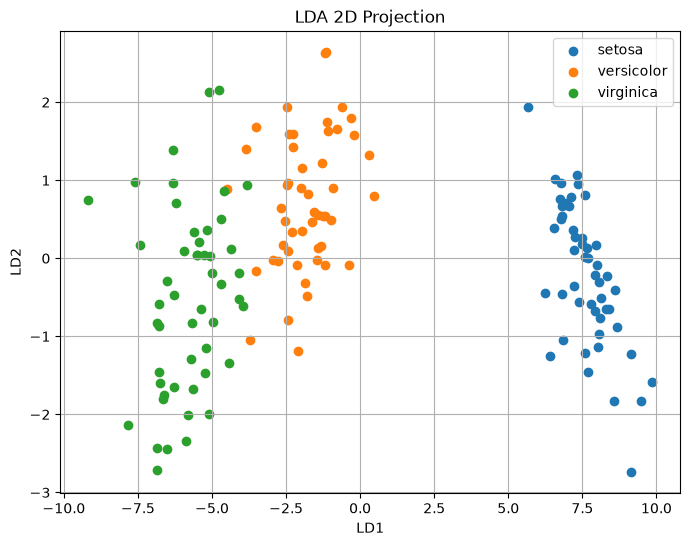

In [10]:
plt.figure(figsize=(8, 6))

for label, class_name in enumerate(iris.target_names):

    mask = y == label

    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        label=class_name
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA 2D Projection")

plt.legend()
plt.grid()

plt.show()

In [11]:
import numpy as np

for label, class_name in enumerate(iris.target_names):

    centroid = X_lda[y == label].mean(axis=0)

    print(
        f"{class_name}: "
        f"LD1={centroid[0]:.3f}, "
        f"LD2={centroid[1]:.3f}"
    )

setosa: LD1=7.608, LD2=-0.215
versicolor: LD1=-1.825, LD2=0.728
virginica: LD1=-5.783, LD2=-0.513


In [12]:
print(lda.scalings_)

[[ 0.68448644 -0.01989153]
 [ 0.66659193 -0.94029176]
 [-3.87282074  1.63962597]
 [-2.13508598 -2.15691008]]


In [13]:
feature_names = iris.feature_names

coef = pd.DataFrame(
    lda.scalings_,
    index=feature_names,
    columns=["LD1", "LD2"]
)

print(coef)

                        LD1       LD2
sepal length (cm)  0.684486 -0.019892
sepal width (cm)   0.666592 -0.940292
petal length (cm) -3.872821  1.639626
petal width (cm)  -2.135086 -2.156910
